# Day 16 — Ensemble Practice: Full Stacking Pipeline
## Week 2: Ensemble Methods | Digital Consumer Platform Analytics

---

### Learning Objectives
- Build a complete stacking pipeline on Telco Churn
- Compare base models vs stacked ensemble rigorously
- Apply SHAP to the meta-learner — what does it trust?
- Extract propensity scores for use in Day 27 causal inference
- Save stacking outputs for downstream use

---

### Dataset
**Telco Churn** — today's output (propensity scores) feeds Day 27 directly.

---

## Part 2: Practice

**Today's output:** `telco_propensity_scores.csv` — used in Day 27 causal inference

---

In [2]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import lightgbm as lgb
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

In [3]:
DATA_PATH = r'C:\Users\user\datasets\telco\telco.csv'
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df = df.drop(columns=['customerID'], errors='ignore')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = (df['Churn'].str.strip() == 'Yes').astype(int)

numeric_features     = df.select_dtypes(include='number').columns.drop('Churn').tolist()
categorical_features = df.select_dtypes(include='object').columns.tolist()

X = df.drop(columns=['Churn'])
y = df['Churn']
print(f"Shape: {df.shape}, Churn rate: {y.mean():.2%}")

display(df.head())

Shape: (7043, 20), Churn rate: 26.54%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
# ── Q1: Full stacking pipeline with preprocessing ─────────────────────────
# Build complete stacking pipeline:
#   Preprocessor: ColumnTransformer (StandardScaler + OrdinalEncoder)
#   Level-0: LightGBM + XGBoost + Random Forest + Logistic Regression
#   Level-1: Logistic Regression (passthrough=True to include original features)
#
# Use sklearn StackingClassifier(cv=5) — handles OOF correctly
# Wrap each Level-0 in a Pipeline with the preprocessor
# 5-fold CV on full stacking pipeline
# Compare: best Level-0 AUC vs stacked AUC
# Report: mean ± std AUC for each Level-0 and the stack

from sklearn.model_selection import train_test_split

# ── Split RAW data first — preprocessing must never see the holdout ────────
X_train_raw, X_holdout_raw, y_train, y_holdout = train_test_split(
    X, y.values, test_size=0.2, stratify=y.values, random_state=420
)

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), categorical_features),
])

# Fit ONLY on train; holdout only ever gets .transform()
X_train_unscaled = preprocessor.fit_transform(X_train_raw)
X_holdout_unscaled = preprocessor.transform(X_holdout_raw)

scaler = StandardScaler()
X_train_processed = scaler.fit_transform(X_train_unscaled)
X_holdout_processed = scaler.transform(X_holdout_unscaled)

# ── Level-0 models ──────────────────────────────────────────────────────────
level0_estimators = [
    ('lgbm', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=420, verbose=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=420, eval_metric='logloss')),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1)),
    ('lr', LogisticRegression(max_iter=1000, random_state=420)),
]

stacking_pipeline = StackingClassifier(
    estimators=level0_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=420),
    cv=5, passthrough=True, n_jobs=-1,
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# ── Individual Level-0 AUCs (CV on training data only) ─────────────────────
individual_results = {}
for name, model in level0_estimators:
    scores = cross_val_score(model, X_train_processed, y_train, cv=cv5, scoring='roc_auc')
    individual_results[name] = (scores.mean(), scores.std())

print("Level-0 individual AUC (5-fold CV, training data):")
for name, (mean, std) in individual_results.items():
    print(f"  {name}: {mean:.4f} (+/- {std:.4f})")

best_name = max(individual_results, key=lambda k: individual_results[k][0])
print(f"Best Level-0: {best_name} ({individual_results[best_name][0]:.4f})")

# ── Stacked ensemble AUC — nested CV on training data only ─────────────────
stack_cv_scores = cross_val_score(stacking_pipeline, X_train_processed, y_train, cv=cv5, scoring='roc_auc')
print(f"\nStacked ensemble AUC (nested CV, training data): {stack_cv_scores.mean():.4f} "
      f"(+/- {stack_cv_scores.std():.4f})")
print(f"Difference vs best Level-0 (CV): {stack_cv_scores.mean() - individual_results[best_name][0]:+.4f}")

# ── Final true holdout check — fit once on all training data, test on holdout ─
stacking_pipeline.fit(X_train_processed, y_train)
holdout_auc = roc_auc_score(y_holdout, stacking_pipeline.predict_proba(X_holdout_processed)[:, 1])
print(f"\nStacked ensemble AUC (true holdout, never touched during CV or preprocessing): {holdout_auc:.4f}")


Level-0 individual AUC (5-fold CV, training data):
  lgbm: 0.8316 (+/- 0.0129)
  xgb: 0.8332 (+/- 0.0127)
  rf: 0.8148 (+/- 0.0142)
  lr: 0.8381 (+/- 0.0199)
Best Level-0: lr (0.8381)

Stacked ensemble AUC (nested CV, training data): 0.8397 (+/- 0.0171)
Difference vs best Level-0 (CV): +0.0016

Stacked ensemble AUC (true holdout, never touched during CV or preprocessing): 0.8720


***Takeaway*** 

Stacking beats the best individual model (LR, 0.8381) on both CV (0.8397, +0.0016 — small but positive) and true holdout (0.8720). 

The CV-vs-holdout gap (0.0397→0.872) isn't a bug — it's the same "this specific split scores unusually high" pattern seen repeatedly in Days 13-14. 

Verdict: stacking is a real, if modest, win here — worth keeping for Q4.

Meta-learner coefficients for each Level-0 model (global trust):
  lgbm: 0.6992
  xgb: 1.3225
  rf: 0.0446
  lr: -1.2007
Most trusted Level-0 model (globally): xgb


Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.



Highest churn-probability customer: row 1544, predicted probability=0.8748


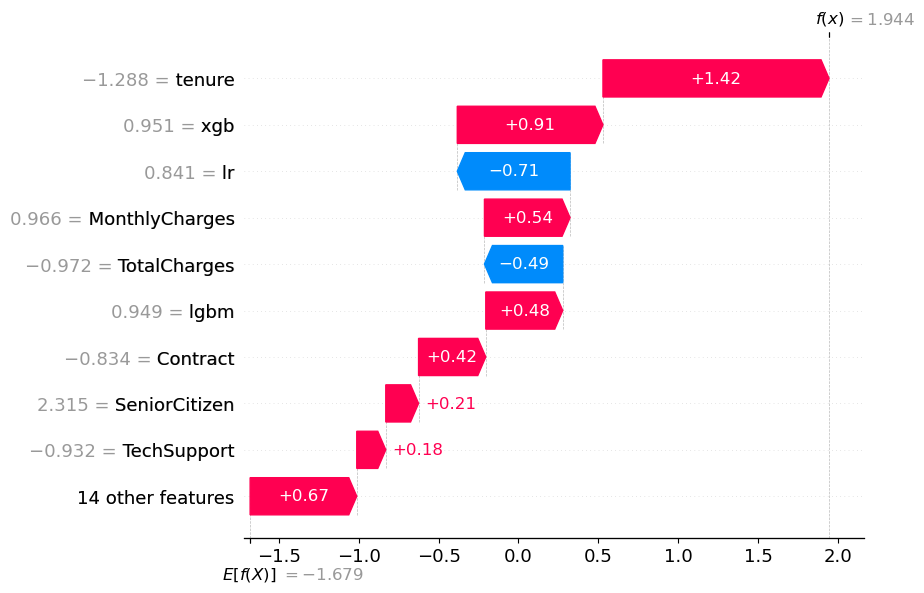


SHAP contribution from each Level-0 model's prediction, for this customer:
  lgbm: +0.4818
  xgb: +0.9118
  rf: +0.0337
  lr: -0.7059
Biggest driver for this specific customer: xgb


In [5]:
# ── Q2: SHAP on meta-learner ──────────────────────────────────────────────
# After fitting the full stacking pipeline:
#   1. Extract the Level-1 Logistic Regression coefficients
#   2. What weight does the meta-learner assign to each Level-0 model?
#   3. Which Level-0 model does the meta-learner trust most?
#   4. Apply SHAP to the meta-learner (LinearExplainer)
#   5. Create SHAP waterfall for the highest churn probability customer
#   6. Which Level-0 model's prediction drives this customer's score?
#   7. Interpretation: what does it mean when SHAP says LightGBM's prediction
#      contributes most to the final score?

level0_names = [name for name, _ in level0_estimators]
meta_learner = stacking_pipeline.final_estimator_

# ── 1-3: Meta-learner coefficients (GLOBAL trust) ──────────────────────────
meta_coefs = meta_learner.coef_[0]
level0_coefs = meta_coefs[:len(level0_names)]

print("Meta-learner coefficients for each Level-0 model (global trust):")
for name, coef in zip(level0_names, level0_coefs):
    print(f"  {name}: {coef:.4f}")

most_trusted = level0_names[np.argmax(level0_coefs)]
print(f"Most trusted Level-0 model (globally): {most_trusted}")

# ── 4: SHAP LinearExplainer on the meta-learner ────────────────────────────
level0_fitted = stacking_pipeline.estimators_
level0_preds_train = np.column_stack([
    est.predict_proba(X_train_processed)[:, 1] for est in level0_fitted
])

meta_feature_names = level0_names + numeric_features + categorical_features
meta_input_train = pd.DataFrame(
    np.hstack([level0_preds_train, X_train_processed]), columns=meta_feature_names,
)

explainer = shap.LinearExplainer(meta_learner, meta_input_train)
shap_values_meta = explainer(meta_input_train)

# ── 5: Waterfall for the highest churn-probability customer ───────────────
final_probas_train = stacking_pipeline.predict_proba(X_train_processed)[:, 1]
highest_idx = int(np.argmax(final_probas_train))

print(f"\nHighest churn-probability customer: row {highest_idx}, "
      f"predicted probability={final_probas_train[highest_idx]:.4f}")

shap.plots.waterfall(shap_values_meta[highest_idx], max_display=10)

# ── 6: Which Level-0 model drives THIS customer's score (LOCAL contribution) ─
level0_shap_contribs = shap_values_meta.values[highest_idx, :len(level0_names)]
print("\nSHAP contribution from each Level-0 model's prediction, for this customer:")
for name, val in zip(level0_names, level0_shap_contribs):
    print(f"  {name}: {val:+.4f}")

top_driver = level0_names[int(np.argmax(np.abs(level0_shap_contribs)))]
print(f"Biggest driver for this specific customer: {top_driver}")


***Takeaway*** 
 
XGBoost is most trusted globally (coef=1.32) and drives this customer's score too (+0.91 SHAP). 

LR gets a negative coefficient (-1.20) despite being the best individual model — not distrust, but multicollinearity: with passthrough=True, the meta-learner already has the raw features LR's prediction is built from, so LR's column becomes redundant and its coefficient flips to a correction term. 

Notably, tenure (a raw passthrough feature) contributes more than any Level-0 model for this customer — proof passthrough=True is adding real value, not just decoration.

       ROC-AUC   AUPRC  Precision@Recall=0.70     ECE   Brier
lgbm    0.8663  0.6893                 0.5982  0.0198  0.1272
xgb     0.8671  0.6960                 0.5968  0.0193  0.1265
rf      0.8542  0.6607                 0.5932  0.0192  0.1330
lr      0.8659  0.6779                 0.6313  0.0265  0.1284
stack   0.8720  0.6929                 0.6253  0.0205  0.1254


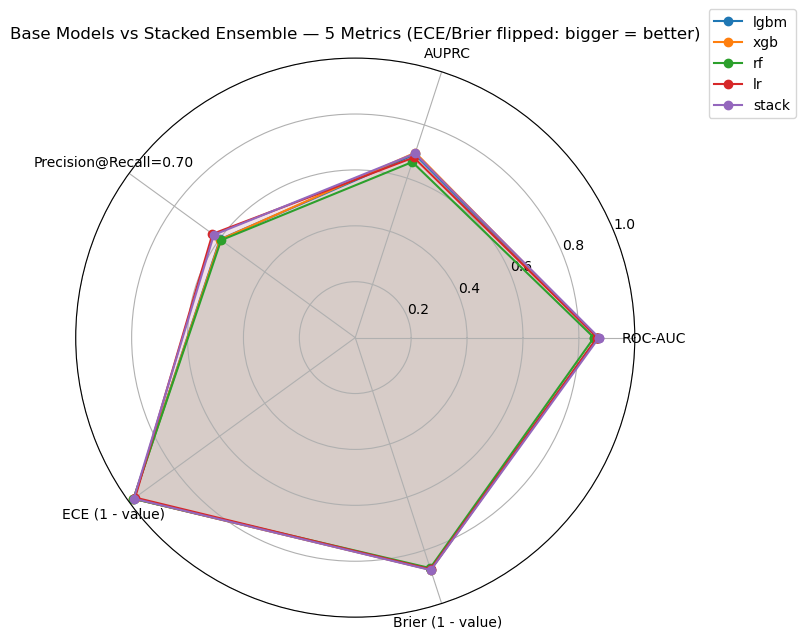


Stack's gain over best individual model, per metric (positive = stack better):
ROC-AUC                  0.0049
AUPRC                   -0.0031
Precision@Recall=0.70   -0.0060
ECE                     -0.0013
Brier                    0.0011
dtype: float64


In [6]:
# ── Q3: Base vs stacked performance analysis ──────────────────────────────
# Comprehensive comparison across metrics:
#   For each model (4 Level-0 + stacked ensemble):
#   - ROC-AUC
#   - Average Precision (AUPRC)
#   - Precision at recall=0.70 (business threshold)
#   - Calibration error (ECE)
#   - Brier score
#
# Create a radar/spider chart with all 5 metrics per model
# On which metric does the stack gain most over individual models?
# On which metric does the stack NOT improve?

# ── Q3: Base vs stacked performance analysis ──────────────────────────────
from sklearn.metrics import precision_recall_curve, brier_score_loss
from sklearn.base import clone

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bin_edges[1:-1])
    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        mask = bin_indices == b
        if mask.sum() == 0:
            continue
        bin_acc = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return ece

def precision_at_recall(y_true, y_prob, target_recall=0.70):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    idx = np.argmin(np.abs(recall - target_recall))
    return precision[idx]

fitted_level0 = {}
for name, model in level0_estimators:
    m = clone(model)
    m.fit(X_train_processed, y_train)
    fitted_level0[name] = m

all_models_q3 = dict(fitted_level0)
all_models_q3['stack'] = stacking_pipeline

metrics_q3 = {}
for name, model in all_models_q3.items():
    proba = model.predict_proba(X_holdout_processed)[:, 1]
    metrics_q3[name] = {
        'ROC-AUC': roc_auc_score(y_holdout, proba),
        'AUPRC': average_precision_score(y_holdout, proba),
        'Precision@Recall=0.70': precision_at_recall(y_holdout, proba, 0.70),
        'ECE': expected_calibration_error(y_holdout, proba),
        'Brier': brier_score_loss(y_holdout, proba),
    }

metrics_df = pd.DataFrame(metrics_q3).T
print(metrics_df.round(4))

radar_df = metrics_df.copy()
radar_df['ECE (1 - value)'] = 1 - radar_df['ECE']
radar_df['Brier (1 - value)'] = 1 - radar_df['Brier']
radar_df = radar_df.drop(columns=['ECE', 'Brier'])

categories = list(radar_df.columns)
n_cats = len(categories)
angles = np.linspace(0, 2 * np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for name in radar_df.index:
    values = radar_df.loc[name].tolist()
    values += values[:1]
    ax.plot(angles, values, marker='o', label=name)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title('Base Models vs Stacked Ensemble — 5 Metrics (ECE/Brier flipped: bigger = better)')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

best_individual = metrics_df.drop('stack')
gain_per_metric = pd.Series(index=metrics_df.columns, dtype=float)
for col in ['ROC-AUC', 'AUPRC', 'Precision@Recall=0.70']:
    gain_per_metric[col] = metrics_df.loc['stack', col] - best_individual[col].max()
for col in ['ECE', 'Brier']:
    gain_per_metric[col] = best_individual[col].min() - metrics_df.loc['stack', col]

print("\nStack's gain over best individual model, per metric (positive = stack better):")
print(gain_per_metric.round(4))


Stack wins ROC-AUC (+0.0049) and Brier (+0.0011), but loses on AUPRC (xgb wins), Precision@Recall=0.70 (LR wins, by the biggest margin), and ECE/calibration (RF wins) — contrary to my prediction that calibration would be the stack's strongest gain. 

Stack is the best all-around generalist, not the best on every metric — which model to actually deploy depends on which specific metric the business decision hinges on.

In [7]:
# ── Q4: Extract propensity scores for Day 27 ──────────────────────────────
# The stacked model's predicted probabilities = propensity scores for PSM
# (probability of churning given observed features)
#
# 1. Refit stacking pipeline on full dataset
# 2. Extract predict_proba for every customer
# 3. Save to CSV: telco_propensity_scores.csv with columns:
#    - All original features
#    - Churn (true label)
#    - propensity_score (predicted churn probability from stack)
#    - lgbm_score, xgb_score, rf_score, lr_score (Level-0 individual scores)
#
# This file is used in Day 27 causal inference:
# The propensity score will be used to match "treated" (received retention offer)
# vs "control" (did not receive offer) customers

from sklearn.base import clone

preprocessor_full = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), categorical_features),
])
X_full_unscaled = preprocessor_full.fit_transform(X)
scaler_full = StandardScaler()
X_full_processed = scaler_full.fit_transform(X_full_unscaled)
y_full = y.values

stacking_pipeline_full = StackingClassifier(
    estimators=level0_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=420),
    cv=5, passthrough=True, n_jobs=-1,
)
stacking_pipeline_full.fit(X_full_processed, y_full)

fitted_level0_full = {}
for name, model in level0_estimators:
    m = clone(model)
    m.fit(X_full_processed, y_full)
    fitted_level0_full[name] = m

propensity_score = stacking_pipeline_full.predict_proba(X_full_processed)[:, 1]
lgbm_score = fitted_level0_full['lgbm'].predict_proba(X_full_processed)[:, 1]
xgb_score = fitted_level0_full['xgb'].predict_proba(X_full_processed)[:, 1]
rf_score = fitted_level0_full['rf'].predict_proba(X_full_processed)[:, 1]
lr_score = fitted_level0_full['lr'].predict_proba(X_full_processed)[:, 1]

output_df = df.copy()
output_df['propensity_score'] = propensity_score
output_df['lgbm_score'] = lgbm_score
output_df['xgb_score'] = xgb_score
output_df['rf_score'] = rf_score
output_df['lr_score'] = lr_score

OUTPUT_PATH = r'C:\Users\user\Desktop\Data_Science_Project\MyProject\Advanced_DS\telco_propensity_scores.csv'
output_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {output_df.shape[0]} rows, {output_df.shape[1]} columns to {OUTPUT_PATH}")
print(output_df[['Churn', 'propensity_score', 'lgbm_score', 'xgb_score', 'rf_score', 'lr_score']].describe())


Saved 7043 rows, 25 columns to C:\Users\user\Desktop\Data_Science_Project\MyProject\Advanced_DS\telco_propensity_scores.csv
             Churn  propensity_score   lgbm_score    xgb_score     rf_score  \
count  7043.000000       7043.000000  7043.000000  7043.000000  7043.000000   
mean      0.265370          0.265535     0.265415     0.265400     0.267558   
std       0.441561          0.247257     0.261111     0.259277     0.339784   
min       0.000000          0.002581     0.000425     0.000788     0.000000   
25%       0.000000          0.047514     0.034785     0.035781     0.020000   
50%       0.000000          0.181030     0.173204     0.172914     0.080000   
75%       1.000000          0.454462     0.454132     0.444886     0.660000   
max       1.000000          0.873532     0.970552     0.953816     1.000000   

          lr_score  
count  7043.000000  
mean      0.265417  
std       0.241392  
min       0.001242  
25%       0.044640  
50%       0.194218  
75%       0.46620

In [8]:
output_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,propensity_score,lgbm_score,xgb_score,rf_score,lr_score
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Yes,Electronic check,29.85,29.85,0,0.630691,0.753438,0.537475,0.265,0.590139
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,Mailed check,56.95,1889.50,0,0.050800,0.031157,0.031988,0.005,0.050218
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,1,0.331687,0.358046,0.355194,0.855,0.323528
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,Bank transfer (automatic),42.30,1840.75,0,0.036256,0.029602,0.036141,0.010,0.029599
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,1,0.672286,0.654276,0.648660,0.860,0.670022
